# Proyecto Final — Data Science II

# BTC / DXY / Oro / VIX

## Notebook 05 — Integración multi-activo

Curso: Data Science II — Machine Learning para Ciencia de Datos  
Coderhouse | 2025–2026

---

Este notebook corresponde a la etapa de integración multi-activo del proyecto BTC/DXY/Oro/VIX.

A partir de los datasets procesados en los notebooks anteriores, se construirá un dataset integrado que permita analizar conjuntamente el comportamiento de:

- Bitcoin,
- DXY,
- Oro,
- y VIX.

El objetivo principal de este bloque es alinear temporalmente las series, validar diferencias de calendario financiero y generar una base única para las etapas posteriores de Feature Engineering, EDA financiero y modelado.

# Contexto metodológico

Los notebooks 01 a 04 construyeron datasets individuales para cada activo, aplicando una estructura homogénea de:

- adquisición,
- limpieza estructural,
- validación temporal,
- construcción de features iniciales,
- EDA de validación,
- y export a `data/processed/`.

En este notebook comienza la fase de integración del proyecto.

A diferencia de los notebooks anteriores, el objetivo ya no es analizar activos por separado, sino construir una estructura temporal común que permita comparar y modelar relaciones entre ellos.

Esta etapa es crítica porque los activos no comparten exactamente el mismo calendario operativo:

- BTC opera todos los días,
- DXY, Oro y VIX operan bajo calendario financiero tradicional,
- y VIX puede presentar pequeñas diferencias adicionales respecto a DXY y Oro.

Por lo tanto, antes de unir los datasets será necesario revisar fechas, gaps, intersecciones y posibles pérdidas de observaciones.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_PATH = r"C:\DS2_BTC_DXY_ORO_VIX"

processed_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

# 1. Carga de datasets procesados

Se cargan los cuatro datasets procesados generados en los notebooks anteriores:

- `btc_processed.csv`
- `dxy_processed.csv`
- `gold_processed.csv`
- `vix_processed.csv`

Cada archivo representa un activo ya adquirido, validado y exportado individualmente.

En esta etapa se recuperan esos outputs para comenzar el proceso de integración multi-activo.

In [3]:
btc_df = pd.read_csv(
    os.path.join(processed_path, "btc_processed.csv"),
    index_col=0,
    parse_dates=True
)

dxy_df = pd.read_csv(
    os.path.join(processed_path, "dxy_processed.csv"),
    index_col=0,
    parse_dates=True
)

gold_df = pd.read_csv(
    os.path.join(processed_path, "gold_processed.csv"),
    index_col=0,
    parse_dates=True
)

vix_df = pd.read_csv(
    os.path.join(processed_path, "vix_processed.csv"),
    index_col=0,
    parse_dates=True
)

# 2. Validación inicial de datasets cargados

Antes de comenzar la integración multi-activo, se realiza una validación básica de los datasets cargados.

El objetivo es confirmar:

- cantidad de registros por activo,
- rango temporal disponible,
- coherencia general de las series,
- y posibles diferencias iniciales de calendario.

In [4]:
print("=== VALIDACIÓN INICIAL DE DATASETS ===")

print()

print(
    f"BTC  : {btc_df.shape[0]} registros | "
    f"{btc_df.index.min().date()} → {btc_df.index.max().date()}"
)

print(
    f"DXY  : {dxy_df.shape[0]} registros | "
    f"{dxy_df.index.min().date()} → {dxy_df.index.max().date()}"
)

print(
    f"ORO  : {gold_df.shape[0]} registros | "
    f"{gold_df.index.min().date()} → {gold_df.index.max().date()}"
)

print(
    f"VIX  : {vix_df.shape[0]} registros | "
    f"{vix_df.index.min().date()} → {vix_df.index.max().date()}"
)

=== VALIDACIÓN INICIAL DE DATASETS ===

BTC  : 1097 registros | 2023-05-06 → 2026-05-06
DXY  : 754 registros | 2023-05-08 → 2026-05-06
ORO  : 754 registros | 2023-05-08 → 2026-05-06
VIX  : 752 registros | 2023-05-08 → 2026-05-06


# 3. Comparación de calendarios

Antes de integrar los activos en un único dataset, se comparan los calendarios temporales disponibles.

El objetivo es identificar:

- fechas exclusivas de BTC,
- posibles diferencias entre DXY y Oro,
- fechas ausentes en VIX,
- y el tamaño real de la intersección temporal entre todos los activos.

Esta validación permitirá definir posteriormente la estrategia de integración más adecuada.

In [5]:
print("=== DIFERENCIAS DE CALENDARIO ===")

print()

print(
    "Fechas presentes en BTC y ausentes en DXY:",
    len(set(btc_df.index) - set(dxy_df.index))
)

print(
    "Fechas presentes en DXY y ausentes en BTC:",
    len(set(dxy_df.index) - set(btc_df.index))
)

print()

print(
    "Fechas presentes en DXY y ausentes en VIX:",
    len(set(dxy_df.index) - set(vix_df.index))
)

print(
    "Fechas presentes en VIX y ausentes en DXY:",
    len(set(vix_df.index) - set(dxy_df.index))
)

=== DIFERENCIAS DE CALENDARIO ===

Fechas presentes en BTC y ausentes en DXY: 343
Fechas presentes en DXY y ausentes en BTC: 0

Fechas presentes en DXY y ausentes en VIX: 2
Fechas presentes en VIX y ausentes en DXY: 0


In [6]:
fechas_faltantes_vix = sorted(
    list(
        set(dxy_df.index) - set(vix_df.index)
    )
)

fechas_faltantes_vix

[Timestamp('2025-01-09 00:00:00'), Timestamp('2025-05-26 00:00:00')]

Durante la comparación de calendarios se detectó que el dataset VIX presenta dos fechas menos que DXY y Oro:

- 2025-01-09
- 2025-05-26

Estas diferencias representan una proporción mínima del dataset y serán consideradas durante la etapa de integración temporal.

No se identificaron inconsistencias estructurales adicionales.

# 4. Preparación de columnas para integración

Antes de integrar los datasets, se renombran las columnas de cada activo.

El objetivo es evitar conflictos de nombres durante la unión de los DataFrames y facilitar la identificación posterior de cada variable dentro del dataset integrado.

Cada columna conservará el nombre original precedido por el identificador del activo correspondiente.

In [7]:
btc_df = btc_df.add_prefix("btc_")

dxy_df = dxy_df.add_prefix("dxy_")

gold_df = gold_df.add_prefix("gold_")

vix_df = vix_df.add_prefix("vix_")

# 5. Integración inicial multi-activo

Se integran los cuatro datasets procesados utilizando el índice temporal como clave común.

La estrategia adoptada es construir un dataset donde cada fila represente una fecha compartida por los activos integrados.

Inicialmente se realiza una unión sobre el calendario compartido disponible, priorizando consistencia temporal y evitando imputaciones masivas sobre días donde algunos mercados no operaron.

In [8]:
integrated_df = (
    dxy_df
    .join(gold_df, how="inner")
    .join(vix_df, how="inner")
    .join(btc_df, how="inner")
)

## Decisión de integración temporal

Aunque DXY y Oro comparten el calendario financiero más completo entre los activos tradicionales, la integración final se realiza mediante una intersección temporal pura (`INNER JOIN`) entre los cuatro datasets.

Como consecuencia, las dos fechas presentes en DXY y Oro pero ausentes en VIX quedan excluidas automáticamente del dataset integrado.

Esta decisión evita la imputación de observaciones para fechas donde alguno de los activos no dispone de información real y garantiza que cada fila represente una observación simultánea de BTC, DXY, Oro y VIX.

Dado que el objetivo de esta etapa es realizar análisis multivariado entre activos, se prioriza trabajar únicamente con fechas compartidas por todas las variables, asegurando comparabilidad temporal completa y evitando la incorporación de datos artificiales.

El dataset integrado resultante contiene exclusivamente observaciones donde los cuatro activos existen simultáneamente dentro del mismo contexto temporal.

# 6. Validación del dataset integrado

Luego de la integración multi-activo, se realiza una validación estructural del dataset resultante.

El objetivo es confirmar:

- cantidad final de observaciones,
- rango temporal disponible,
- ausencia de duplicados temporales,
- consistencia general de la integración,
- y presencia de valores faltantes.

In [9]:
print("=== VALIDACIÓN DATASET INTEGRADO ===")

print()

print(
    f"Shape: {integrated_df.shape}"
)

print()

print(
    f"Rango temporal: "
    f"{integrated_df.index.min().date()} "
    f"→ "
    f"{integrated_df.index.max().date()}"
)

print()

print(
    f"Duplicados temporales: "
    f"{integrated_df.index.duplicated().sum()}"
)

print()

print(
    f"Total de NaN: "
    f"{integrated_df.isna().sum().sum()}"
)

=== VALIDACIÓN DATASET INTEGRADO ===

Shape: (752, 32)

Rango temporal: 2023-05-08 → 2026-05-06

Duplicados temporales: 0

Total de NaN: 51


In [10]:
integrated_df.isna().sum().sort_values(ascending=False)

dxy_volatility_7d     7
gold_volatility_7d    7
vix_volatility_7d     7
gold_ma_7d            6
vix_ma_7d             6
dxy_ma_7d             6
btc_volatility_7d     5
btc_ma_7d             4
dxy_return            1
gold_return           1
vix_return            1
dxy_Low               0
dxy_Volume            0
dxy_High              0
dxy_Open              0
dxy_Close             0
gold_Volume           0
gold_High             0
gold_Low              0
gold_Open             0
gold_Close            0
vix_Low               0
vix_Open              0
vix_Close             0
vix_Volume            0
vix_High              0
btc_Close             0
btc_High              0
btc_Open              0
btc_Low               0
btc_return            0
btc_Volume            0
dtype: int64

## Validación del dataset integrado

La integración multi-activo generó un dataset final de 752 observaciones y 32 variables, correspondientes a los cuatro activos analizados y sus features derivadas.

La validación estructural confirmó:

- ausencia de duplicados temporales,
- consistencia del rango temporal compartido,
- correcta integración mediante intersección temporal,
- y presencia exclusiva de valores faltantes esperados derivados de la construcción de features rolling.

Se detectaron 51 valores faltantes distribuidos entre las variables de retornos, volatilidad móvil y medias móviles.

La diferencia respecto a los 56 valores faltantes teóricos originales se explica por la eliminación automática de las dos primeras fechas exclusivas de Bitcoin durante el proceso de integración, reduciendo parte de los NaN iniciales asociados a sus features temporales.

No se identificaron valores faltantes inesperados ni inconsistencias estructurales adicionales.

# 7. Inspección general del dataset integrado

Se realiza una inspección inicial del dataset integrado con el objetivo de verificar:

- estructura general,
- tipos de datos,
- variables disponibles,
- y primeras observaciones del conjunto consolidado.

Esta revisión permite confirmar que la integración produjo el resultado esperado antes de avanzar hacia análisis multivariados.

In [11]:
integrated_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 752 entries, 2023-05-08 to 2026-05-06
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dxy_Close           752 non-null    float64
 1   dxy_High            752 non-null    float64
 2   dxy_Low             752 non-null    float64
 3   dxy_Open            752 non-null    float64
 4   dxy_Volume          752 non-null    int64  
 5   dxy_return          751 non-null    float64
 6   dxy_volatility_7d   745 non-null    float64
 7   dxy_ma_7d           746 non-null    float64
 8   gold_Close          752 non-null    float64
 9   gold_High           752 non-null    float64
 10  gold_Low            752 non-null    float64
 11  gold_Open           752 non-null    float64
 12  gold_Volume         752 non-null    int64  
 13  gold_return         751 non-null    float64
 14  gold_volatility_7d  745 non-null    float64
 15  gold_ma_7d          746 non-null    float64
 16  

In [12]:
integrated_df.head(10)

,dxy_Close,dxy_High,dxy_Low,dxy_Open,dxy_Volume,dxy_return,dxy_volatility_7d,dxy_ma_7d,gold_Close,gold_High,...,vix_volatility_7d,vix_ma_7d,btc_Close,btc_High,btc_Low,btc_Open,btc_Volume,btc_return,btc_volatility_7d,btc_ma_7d
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-08,101.370003,101.419998,101.040001,101.279999,0,NaN,NaN,NaN,2026.300049,2026.300049,...,NaN,NaN,27694.273438,28663.271484,27310.134766,28450.457031,19122903752,-0.026734,NaN,NaN
2023-05-09,101.639999,101.839996,101.360001,101.400002,0,0.002663,NaN,NaN,2036.199951,2037.300049,...,NaN,NaN,27658.775391,27821.400391,27375.601562,27695.068359,14128593256,-0.001282,NaN,NaN
2023-05-10,101.480003,101.809998,101.220001,101.620003,0,-0.001574,NaN,NaN,2030.500000,2044.300049,...,NaN,NaN,27621.755859,28322.687500,26883.669922,27654.636719,20656025026,-0.001338,NaN,NaN
2023-05-11,102.059998,102.150002,101.300003,101.410004,0,0.005715,NaN,NaN,2014.699951,2038.300049,...,NaN,NaN,27000.789062,27621.941406,26781.826172,27621.085938,16724343943,-0.022481,NaN,NaN
2023-05-12,102.680000,102.709999,101.940002,102.099998,0,0.006075,NaN,NaN,2014.500000,2014.500000,...,NaN,NaN,26804.990234,27055.646484,25878.429688,26987.662109,19313599897,-0.007252,NaN,27734.312221
2023-05-15,102.430000,102.750000,102.379997,102.709999,0,-0.002435,NaN,NaN,2018.000000,2018.000000,...,NaN,NaN,27192.693359,27646.347656,26766.097656,26931.384766,14413231792,0.009731,0.010334,27141.960100
2023-05-16,102.559998,102.690002,102.199997,102.430000,0,0.001269,NaN,102.031429,1988.400024,1988.400024,...,NaN,17.242857,27036.650391,27299.304688,26878.947266,27171.513672,12732238816,-0.005738,0.010379,27053.085100
2023-05-17,102.879997,103.110001,102.540001,102.610001,0,0.003120,0.003291,102.247142,1980.699951,1983.599976,...,0.041352,17.227143,27398.802734,27465.927734,26600.144531,27035.470703,15140006925,0.013395,0.012160,27021.234654
2023-05-18,103.580002,103.620003,102.800003,102.910004,0,0.006804,0.003746,102.524285,1956.500000,1956.800049,...,0.039877,16.990000,26832.208984,27466.527344,26415.101562,27401.650391,15222938600,-0.020680,0.011640,26997.151786


### Conclusiones de la inspección inicial

La inspección general del dataset integrado confirmó que la integración multi-activo fue realizada correctamente.

Se obtuvo un dataset compuesto por 752 observaciones temporales y 32 variables correspondientes a BTC, DXY, Oro y VIX, incluyendo tanto variables originales como features derivadas.

La revisión de tipos de datos confirmó que todas las variables numéricas fueron preservadas correctamente, sin conversiones inesperadas ni problemas de estructura.

Los valores faltantes observados corresponden exclusivamente a NaN esperados derivados del cálculo de retornos, medias móviles y volatilidades rolling durante los primeros registros de cada serie temporal.

No se identificaron inconsistencias estructurales, duplicados temporales ni anomalías en la integración.

Con estas validaciones completadas, el dataset se considera apto para avanzar hacia las etapas de análisis estadístico y EDA multivariado.

# 8. Resumen estadístico inicial

Antes de avanzar hacia el análisis multivariado, se realiza una revisión descriptiva de las variables numéricas presentes en el dataset integrado.

El objetivo es identificar:

- rangos de valores,
- medidas de tendencia central,
- dispersión,
- posibles anomalías,
- y diferencias de escala entre activos.

Esta etapa permite verificar que las variables presentan comportamientos coherentes antes de aplicar técnicas de correlación y análisis conjunto.

In [13]:
integrated_df.describe().T

,count,mean,std,min,25%,50%,75%,max
dxy_Close,752.0,1.022981e+02,3.210568e+00,9.622000e+01,9.921250e+01,1.028700e+02,1.045700e+02,1.099600e+02
dxy_High,752.0,1.025953e+02,3.207582e+00,9.666000e+01,9.947000e+01,1.031800e+02,1.049125e+02,1.101800e+02
dxy_Low,752.0,1.019916e+02,3.197256e+00,9.555000e+01,9.886000e+01,1.025050e+02,1.042375e+02,1.094100e+02
dxy_Open,752.0,1.022947e+02,3.202745e+00,9.597000e+01,9.917750e+01,1.028250e+02,1.045650e+02,1.096400e+02
dxy_Volume,752.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dxy_return,751.0,-3.489605e-05,4.130429e-03,-1.972788e-02,-2.507090e-03,1.904625e-04,2.533698e-03,1.614773e-02
dxy_volatility_7d,745.0,3.862333e-03,1.509461e-03,6.639661e-04,2.724429e-03,3.699487e-03,4.584132e-03,1.055792e-02
dxy_ma_7d,746.0,1.023157e+02,3.184030e+00,9.686143e+01,9.916571e+01,1.029307e+02,1.046232e+02,1.093514e+02
gold_Close,752.0,2.924974e+03,9.516661e+02,1.816600e+03,2.038550e+03,2.644550e+03,3.381525e+03,5.318400e+03
gold_High,752.0,2.943237e+03,9.653555e+02,1.826300e+03,2.047850e+03,2.657300e+03,3.396050e+03,5.586200e+03


### Conclusiones del resumen estadístico

El análisis descriptivo confirmó que las variables presentan comportamientos coherentes con la naturaleza financiera de cada activo.

Se observaron diferencias claras de escala entre BTC, DXY, Oro y VIX, así como distintos niveles de volatilidad y dispersión.

Los retornos medios diarios resultaron pequeños en comparación con sus respectivas volatilidades, comportamiento habitual en series financieras.

La volatilidad promedio observada siguió el orden esperado:

DXY < Oro < BTC < VIX

lo que refuerza la consistencia de los datos procesados y de las features generadas.

No se identificaron valores anómalos, inconsistencias estadísticas ni rangos incompatibles con la dinámica esperada de los mercados analizados.

Con estas validaciones completadas, el dataset se considera apto para avanzar hacia el análisis multivariado y el estudio de relaciones entre activos.

El análisis descriptivo se realizó sobre la totalidad de las variables disponibles con fines de validación estadística del dataset integrado. 

Los análisis posteriores se concentrarán exclusivamente en las variables relevantes para las hipótesis y el modelado.

# 9. Correlación entre retornos de los activos

En una primera etapa del análisis multivariado se estudian las relaciones lineales entre los retornos diarios de BTC, DXY, Oro y VIX.

Los retornos representan los cambios porcentuales diarios de cada activo y constituyen una de las variables más relevantes para evaluar comportamientos conjuntos entre mercados.

El objetivo es identificar asociaciones positivas o negativas que puedan aportar evidencia para las hipótesis planteadas y servir como base para etapas posteriores de modelado.

In [14]:
returns_corr = integrated_df[
    [
        "btc_return",
        "dxy_return",
        "gold_return",
        "vix_return"
    ]
].corr()

returns_corr

,btc_return,dxy_return,gold_return,vix_return
btc_return,1.000000,-0.053331,0.058500,-0.332721
dxy_return,-0.053331,1.000000,-0.356764,0.043212
gold_return,0.058500,-0.356764,1.000000,-0.045113
vix_return,-0.332721,0.043212,-0.045113,1.000000


### 9.1 Heatmap de correlación de retornos

Para facilitar la interpretación visual de las relaciones observadas, se construye un heatmap utilizando exclusivamente los retornos diarios de BTC, DXY, Oro y VIX.

A diferencia de una matriz de correlación completa del dataset, este enfoque permite concentrarse únicamente en las variables directamente relacionadas con las hipótesis del proyecto, reduciendo ruido visual y facilitando la identificación de patrones relevantes entre activos.

La escala de colores se centra en cero:

- correlaciones positivas representadas en tonos verdes,
- correlaciones negativas representadas en tonos rojos,
- correlaciones cercanas a cero representadas mediante colores neutros.

Esto permite identificar rápidamente asociaciones positivas, negativas o prácticamente inexistentes entre los mercados analizados.

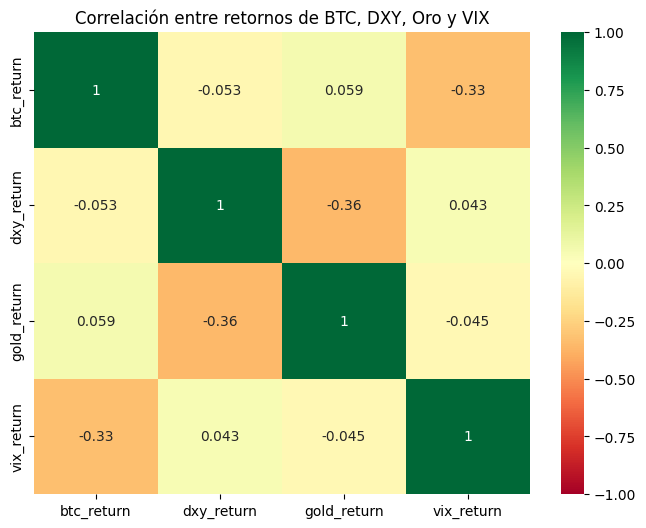

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    returns_corr,
    annot=True,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre retornos de BTC, DXY, Oro y VIX")

plt.show()

### Conclusiones preliminares

El heatmap confirma visualmente los resultados observados en la matriz numérica de correlación.

Las relaciones más destacadas corresponden a:

- BTC ↔ VIX: correlación negativa moderada (-0.33)
- DXY ↔ Oro: correlación negativa moderada (-0.36)

Por otro lado, BTC mostró correlaciones muy débiles tanto con DXY como con Oro durante el período analizado.

Estos resultados sugieren que las relaciones entre activos son más complejas de lo esperado y que algunas narrativas frecuentemente mencionadas en medios financieros no se reflejan de forma evidente en los retornos diarios observados entre 2023 y 2026.

Las correlaciones identificadas constituyen evidencia exploratoria y no implican causalidad entre variables.

# 10. Correlación entre features derivadas

Además de analizar las relaciones entre los retornos de los activos, resulta relevante estudiar el comportamiento conjunto de las variables derivadas construidas durante la etapa de feature engineering.

Estas variables incluyen:

- retornos diarios,
- volatilidades móviles de 7 días,
- medias móviles de 7 días.

El objetivo es identificar posibles asociaciones entre features, detectar relaciones potencialmente redundantes y obtener una visión preliminar de la estructura de información disponible para etapas posteriores de modelado.

In [16]:
feature_columns = [
    "btc_return",
    "btc_volatility_7d",
    "btc_ma_7d",

    "dxy_return",
    "dxy_volatility_7d",
    "dxy_ma_7d",

    "gold_return",
    "gold_volatility_7d",
    "gold_ma_7d",

    "vix_return",
    "vix_volatility_7d",
    "vix_ma_7d"
]

features_corr = integrated_df[feature_columns].corr()

features_corr.round(3)

,btc_return,btc_volatility_7d,btc_ma_7d,dxy_return,dxy_volatility_7d,dxy_ma_7d,gold_return,gold_volatility_7d,gold_ma_7d,vix_return,vix_volatility_7d,vix_ma_7d
btc_return,1.000,0.068,-0.060,-0.053,0.036,0.038,0.059,-0.054,-0.043,-0.333,0.003,0.051
btc_volatility_7d,0.068,1.000,-0.031,-0.068,0.163,0.135,0.048,0.218,0.020,-0.035,0.278,0.191
btc_ma_7d,-0.060,-0.031,1.000,-0.017,0.150,-0.389,0.050,0.287,0.617,0.021,0.157,0.228
dxy_return,-0.053,-0.068,-0.017,1.000,-0.091,-0.036,-0.357,0.011,-0.007,0.043,-0.086,-0.078
dxy_volatility_7d,0.036,0.163,0.150,-0.091,1.000,0.040,-0.030,0.247,-0.002,-0.002,0.347,0.417
dxy_ma_7d,0.038,0.135,-0.389,-0.036,0.040,1.000,-0.009,-0.359,-0.707,0.015,0.033,-0.224
gold_return,0.059,0.048,0.050,-0.357,-0.030,-0.009,1.000,-0.077,0.013,-0.045,0.048,0.028
gold_volatility_7d,-0.054,0.218,0.287,0.011,0.247,-0.359,-0.077,1.000,0.582,0.006,0.195,0.386
gold_ma_7d,-0.043,0.020,0.617,-0.007,-0.002,-0.707,0.013,0.582,1.000,0.008,0.158,0.416
vix_return,-0.333,-0.035,0.021,0.043,-0.002,0.015,-0.045,0.006,0.008,1.000,0.010,-0.075


## 10.1 Heatmap de correlación entre features derivadas

Con el objetivo de facilitar la interpretación visual de la matriz de correlación, se construye un heatmap utilizando exclusivamente las variables derivadas generadas durante la etapa de feature engineering.

A diferencia de una matriz que incluya variables OHLC y volumen, este enfoque se concentra únicamente en las variables con potencial relevancia para etapas posteriores de modelado:

- retornos diarios,
- volatilidades móviles de 7 días,
- medias móviles de 7 días.

La escala de colores permite identificar rápidamente asociaciones positivas, negativas o prácticamente inexistentes entre las features construidas para BTC, DXY, Oro y VIX.

Este análisis tiene como finalidad explorar posibles relaciones entre variables, detectar patrones compartidos entre activos y evaluar preliminarmente la existencia de información redundante dentro del conjunto de features.

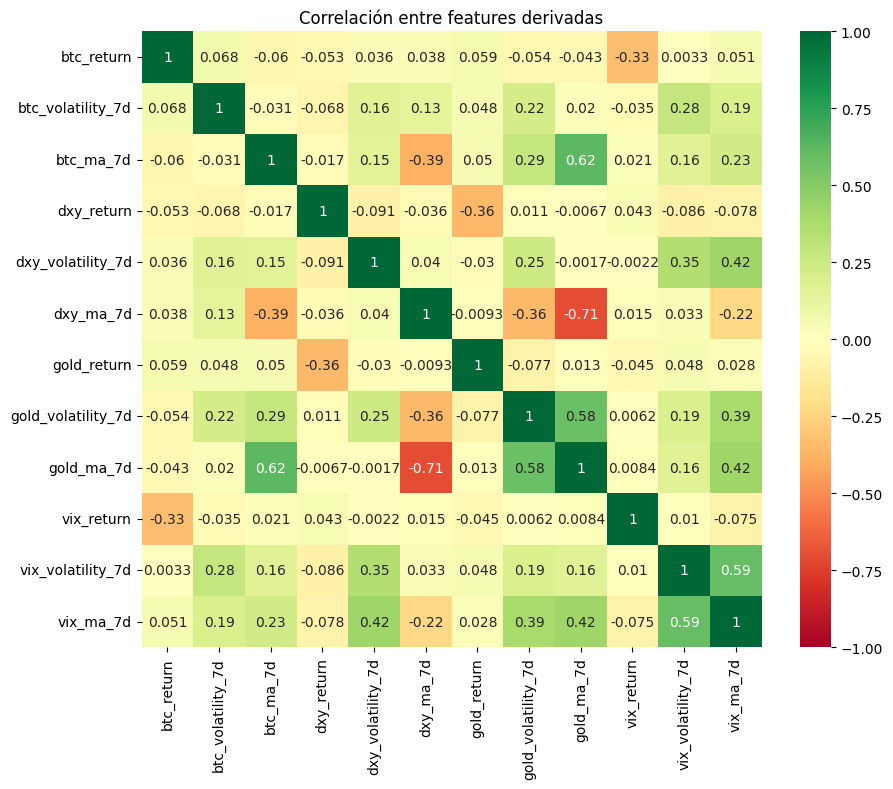

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    features_corr,
    annot=True,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre features derivadas")

plt.show()

### Conclusiones preliminares

El análisis de correlación entre features derivadas mostró relaciones más intensas que las observadas previamente entre los retornos diarios de los activos.

Las asociaciones más destacadas se observaron entre las medias móviles, sugiriendo que algunas relaciones entre mercados se expresan con mayor claridad al analizar tendencias suavizadas de varios días en lugar de movimientos diarios aislados.

Entre los resultados más relevantes se encuentran:

- Correlación negativa fuerte entre `dxy_ma_7d` y `gold_ma_7d` (-0.707).
- Correlación positiva moderada-fuerte entre `btc_ma_7d` y `gold_ma_7d` (0.617).
- Correlación positiva moderada entre `gold_volatility_7d` y `gold_ma_7d` (0.582).
- Correlación positiva moderada entre `vix_volatility_7d` y `vix_ma_7d` (0.594).

NOTA: Cabe señalar que algunas de las correlaciones más elevadas observadas en la matriz corresponden a variables derivadas de un mismo activo, como gold_volatility_7d y gold_ma_7d. Estas asociaciones reflejan relaciones internas de comportamiento dentro del propio mercado y no constituyen evidencia sobre las hipótesis intermercado planteadas en este proyecto.

Por otra parte, la relación negativa observada previamente entre los retornos de BTC y VIX (-0.333) continúa presente dentro del conjunto de features analizadas, reforzando la consistencia de este hallazgo a través de distintas representaciones de los datos.

En términos generales, los resultados sugieren que las relaciones entre activos tienden a manifestarse con mayor intensidad en variables suavizadas y agregadas temporalmente, mientras que los retornos diarios presentan niveles más elevados de ruido y variabilidad de corto plazo.

Estas observaciones constituyen evidencia exploratoria y no implican causalidad entre variables.

# 11. Análisis visual de relaciones relevantes

Las matrices de correlación permiten identificar relaciones lineales entre variables, pero no muestran directamente la distribución de los datos ni la forma en que dichas relaciones se manifiestan.

Por este motivo se construyen gráficos de dispersión (scatterplots) para algunas de las asociaciones más relevantes observadas durante el análisis exploratorio.

El objetivo es complementar la interpretación de las correlaciones mediante una representación visual de los patrones presentes en los datos.

## 11.1 BTC Return vs VIX Return

La relación entre los retornos diarios de BTC y VIX se explora mediante un gráfico de dispersión con el objetivo de complementar la interpretación obtenida a partir de la matriz de correlación.

Cada punto representa una observación diaria compartida por ambos activos:

- Eje X: retorno diario de BTC.
- Eje Y: retorno diario de VIX.

Este tipo de visualización permite observar la distribución de los datos, identificar posibles agrupamientos, detectar valores extremos y evaluar si la relación observada se encuentra distribuida a lo largo de múltiples observaciones o depende de eventos aislados.

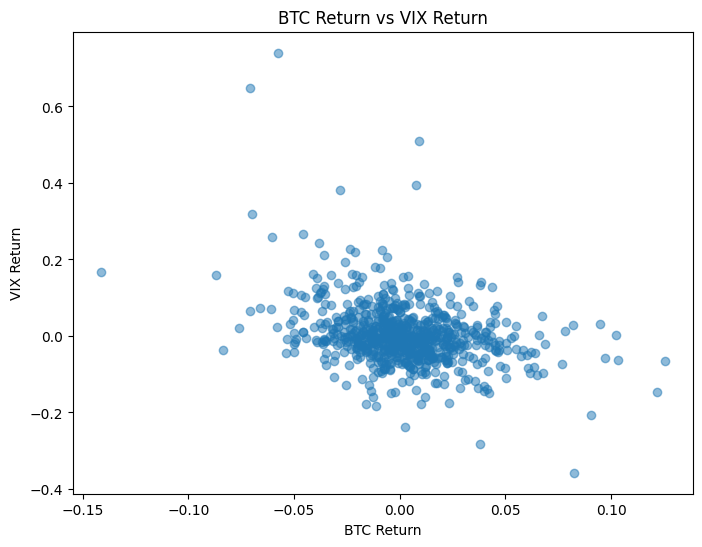

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    integrated_df["btc_return"],
    integrated_df["vix_return"],
    alpha=0.5
)

plt.xlabel("BTC Return")
plt.ylabel("VIX Return")
plt.title("BTC Return vs VIX Return")

plt.show()

### Observaciones

El gráfico de dispersión confirma visualmente la correlación negativa observada previamente entre los retornos de BTC y VIX (-0.333).

Si bien la nube de puntos presenta una dispersión considerable, característica habitual de las series financieras, puede apreciarse una inclinación general negativa consistente con los resultados obtenidos en la matriz de correlación.

Se observan además eventos extremos donde aumentos significativos de VIX coinciden con retornos negativos de BTC, así como situaciones inversas en las que descensos de VIX se asocian con retornos positivos de BTC.

La distribución de los puntos sugiere que la relación no se encuentra explicada únicamente por unos pocos valores atípicos, sino que aparece reflejada en una parte importante de las observaciones del período analizado.

En términos exploratorios, los resultados son compatibles con la interpretación de VIX como indicador de estrés o incertidumbre del mercado, mientras que BTC tiende a comportarse como un activo más sensible a cambios en el apetito por riesgo de los inversores.

Como en los análisis anteriores, la correlación observada no implica causalidad entre variables.

## 11.2 DXY MA 7D vs Gold MA 7D

La correlación más intensa observada durante el análisis de features derivadas corresponde a las medias móviles de 7 días de DXY y Oro.

Con el objetivo de complementar la interpretación obtenida a partir del heatmap, se construye un gráfico de dispersión entre ambas variables.

Al trabajar con medias móviles, las fluctuaciones de corto plazo quedan suavizadas, permitiendo observar con mayor claridad las tendencias predominantes de cada activo a lo largo del tiempo.

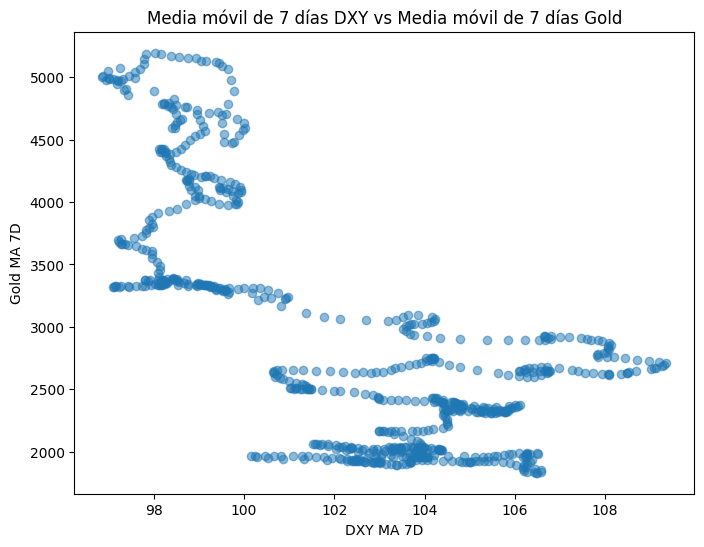

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    integrated_df["dxy_ma_7d"],
    integrated_df["gold_ma_7d"],
    alpha=0.5
)

plt.xlabel("DXY MA 7D")
plt.ylabel("Gold MA 7D")
plt.title("Media móvil de 7 días DXY vs Media móvil de 7 días Gold")

plt.show()

### Observaciones

El gráfico de dispersión confirma visualmente la fuerte correlación negativa observada entre las medias móviles de 7 días de DXY y Oro (-0.707).

A diferencia del gráfico BTC Return vs VIX Return, donde la relación aparece acompañada por una dispersión considerable, en este caso puede observarse una estructura mucho más definida, consistente con una asociación negativa relevante entre ambas variables.

Los períodos de DXY relativamente bajo coinciden con niveles elevados de la media móvil del Oro, mientras que valores más altos de DXY se asocian con niveles más bajos de la media móvil del metal.

Este comportamiento resulta consistente con la correlación observada en la matriz de features y sugiere que ciertas relaciones entre mercados pueden manifestarse con mayor claridad al analizar tendencias suavizadas de varios días en lugar de movimientos diarios aislados.

Si bien el gráfico evidencia una asociación negativa importante, no permite establecer relaciones causales entre ambas variables. La interpretación económica de este comportamiento requiere análisis adicionales y conocimiento del contexto de mercado correspondiente a cada período.

## 11.3 BTC MA 7D vs Gold MA 7D

Además de la relación negativa observada entre DXY y Oro, las medias móviles de 7 días de BTC y Oro presentan una correlación positiva moderada-fuerte (0.617).

Con el objetivo de complementar la interpretación de esta asociación, se construye un gráfico de dispersión entre ambas variables.

Este análisis permite evaluar visualmente si la relación observada en la matriz de correlación se encuentra distribuida a lo largo del conjunto de observaciones o depende de situaciones particulares dentro del período estudiado.

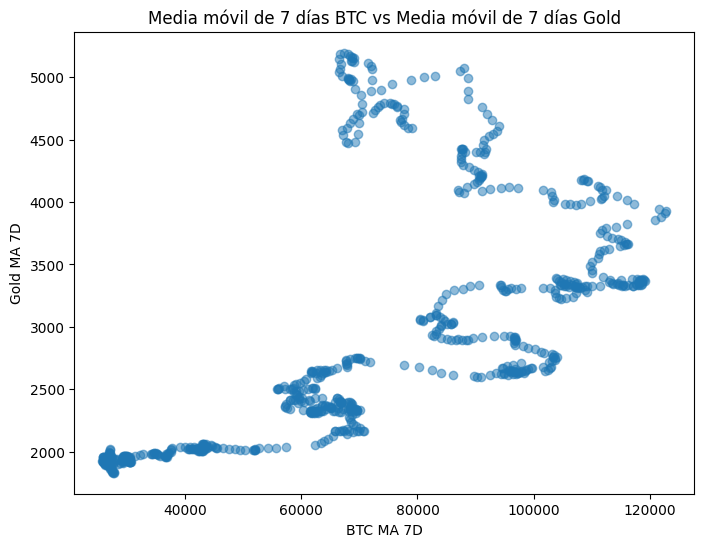

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    integrated_df["btc_ma_7d"],
    integrated_df["gold_ma_7d"],
    alpha=0.5
)

plt.xlabel("BTC MA 7D")
plt.ylabel("Gold MA 7D")
plt.title("Media móvil de 7 días BTC vs Media móvil de 7 días Gold")

plt.show()

### Observaciones

El gráfico de dispersión confirma la correlación positiva moderada-fuerte observada entre las medias móviles de 7 días de BTC y Oro (0.617).

A diferencia de la relación observada entre DXY y Oro, donde la asociación negativa aparece de forma claramente lineal, la relación entre BTC y Oro presenta una estructura más compleja, con diferentes agrupamientos y trayectorias dentro del período analizado.

En términos generales, los períodos de medias móviles elevadas para BTC tienden a coincidir con niveles elevados de la media móvil del Oro, mientras que los períodos de menor nivel en BTC suelen acompañarse de niveles relativamente más bajos en el metal.

Sin embargo, los máximos observados en ambos activos no ocurren necesariamente en los mismos momentos, lo que genera regiones diferenciadas dentro del gráfico donde uno de los activos alcanza niveles excepcionalmente altos mientras el otro permanece en valores más moderados.

Estos resultados sugieren que BTC y Oro compartieron parte de la dirección general de sus tendencias durante el período analizado, aunque respondiendo a dinámicas de mercado diferentes y sin evidencias suficientes para establecer relaciones causales entre ambos activos.

La visualización refuerza además uno de los principales hallazgos del análisis exploratorio: las relaciones entre activos tienden a manifestarse con mayor claridad en variables suavizadas temporalmente que en movimientos diarios aislados.

# 12. Conclusiones del EDA Multivariado

El análisis multivariado permitió estudiar las relaciones existentes entre BTC, DXY, Oro y VIX mediante la combinación de retornos diarios, volatilidades móviles y medias móviles de 7 días.

La utilización conjunta de matrices de correlación, heatmaps y gráficos de dispersión permitió identificar patrones relevantes entre los distintos activos y evaluar el aporte potencial de las features construidas para etapas posteriores de modelado.

Las principales conclusiones, aprendizajes e implicancias obtenidas se resumen en las siguientes subsecciones.

## 12.1 Principales hallazgos

A partir del análisis realizado se identificaron los siguientes resultados relevantes:

- BTC y VIX presentaron una correlación negativa moderada en sus retornos diarios (-0.333), consistente con la interpretación de VIX como indicador de incertidumbre o estrés de mercado.

- DXY y Oro mostraron la relación más intensa observada durante todo el análisis, alcanzando una correlación de -0.707 entre sus medias móviles de 7 días.

- BTC y Oro exhibieron una correlación positiva moderada entre sus medias móviles (0.617), sugiriendo que ambos activos compartieron parte de sus tendencias generales durante el período analizado.

- Las correlaciones observadas entre retornos diarios fueron, en términos generales, más débiles que aquellas observadas en las variables suavizadas mediante medias móviles y volatilidades.

NOTA: Debe considerarse que las medias móviles son series suavizadas que conservan parte de la tendencia general de cada activo. Por este motivo, la correlación observada puede reflejar tendencias compartidas durante el período analizado y no necesariamente una relación estructural entre ambos mercados.

## 12.2 Aprendizajes obtenidos

Uno de los hallazgos más relevantes del análisis fue observar que las relaciones entre activos se manifiestan con mayor claridad al analizar tendencias suavizadas de varios días que al estudiar movimientos diarios aislados.

Los retornos diarios mostraron elevados niveles de ruido y dispersión, mientras que las medias móviles permitieron identificar estructuras y asociaciones más definidas entre distintos mercados.

Asimismo, la inspección visual de los gráficos de dispersión evidenció que un único coeficiente de correlación no siempre captura completamente la estructura subyacente de los datos, reforzando la importancia de complementar las métricas estadísticas con herramientas gráficas durante el proceso exploratorio.

## 12.3 Implicancias para el modelado

Los resultados obtenidos justifican la utilización de un enfoque multivariable para la etapa de modelado.

Ninguna variable individual mostró capacidad suficiente para explicar por sí sola el comportamiento futuro de BTC. Sin embargo, el conjunto de features construidas permitió identificar relaciones complementarias entre distintos mercados y horizontes temporales.

Estas observaciones respaldan la utilización conjunta de retornos, volatilidades y medias móviles como variables explicativas para los modelos predictivos que serán desarrollados en las siguientes etapas del proyecto.